In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations_df.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/interaction_data.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/ratings_matrix.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/user_profiles.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/recommendations.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations.csv


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import timedelta
from tqdm import tqdm
import warnings
import os
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("All imports done")

2026-03-22 08:57:16.761327: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774169837.154776      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774169837.260991      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774169838.212674      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774169838.212716      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774169838.212719      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
All imports done


In [3]:
start_load = time.time()

interaction_data  = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/interaction_data.csv')
presentations     = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations.csv')
presentations_df  = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations_df.csv')
ratings_matrix    = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/ratings_matrix.csv')
recommendations   = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/recommendations.csv')
user_profiles     = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/user_profiles.csv')

print(f"Loaded in {time.time()-start_load:.2f}s")
print(f"interaction_data : {interaction_data.shape}")
print(f"ratings_matrix   : {ratings_matrix.shape}")
print(f"recommendations  : {recommendations.shape}")
print(f"user_profiles    : {user_profiles.shape}")
print(f"presentations    : {presentations.shape}")

Loaded in 0.30s
interaction_data : (25000, 75)
ratings_matrix   : (3000, 5)
recommendations  : (100, 26)
user_profiles    : (30, 5)
presentations    : (78, 15)


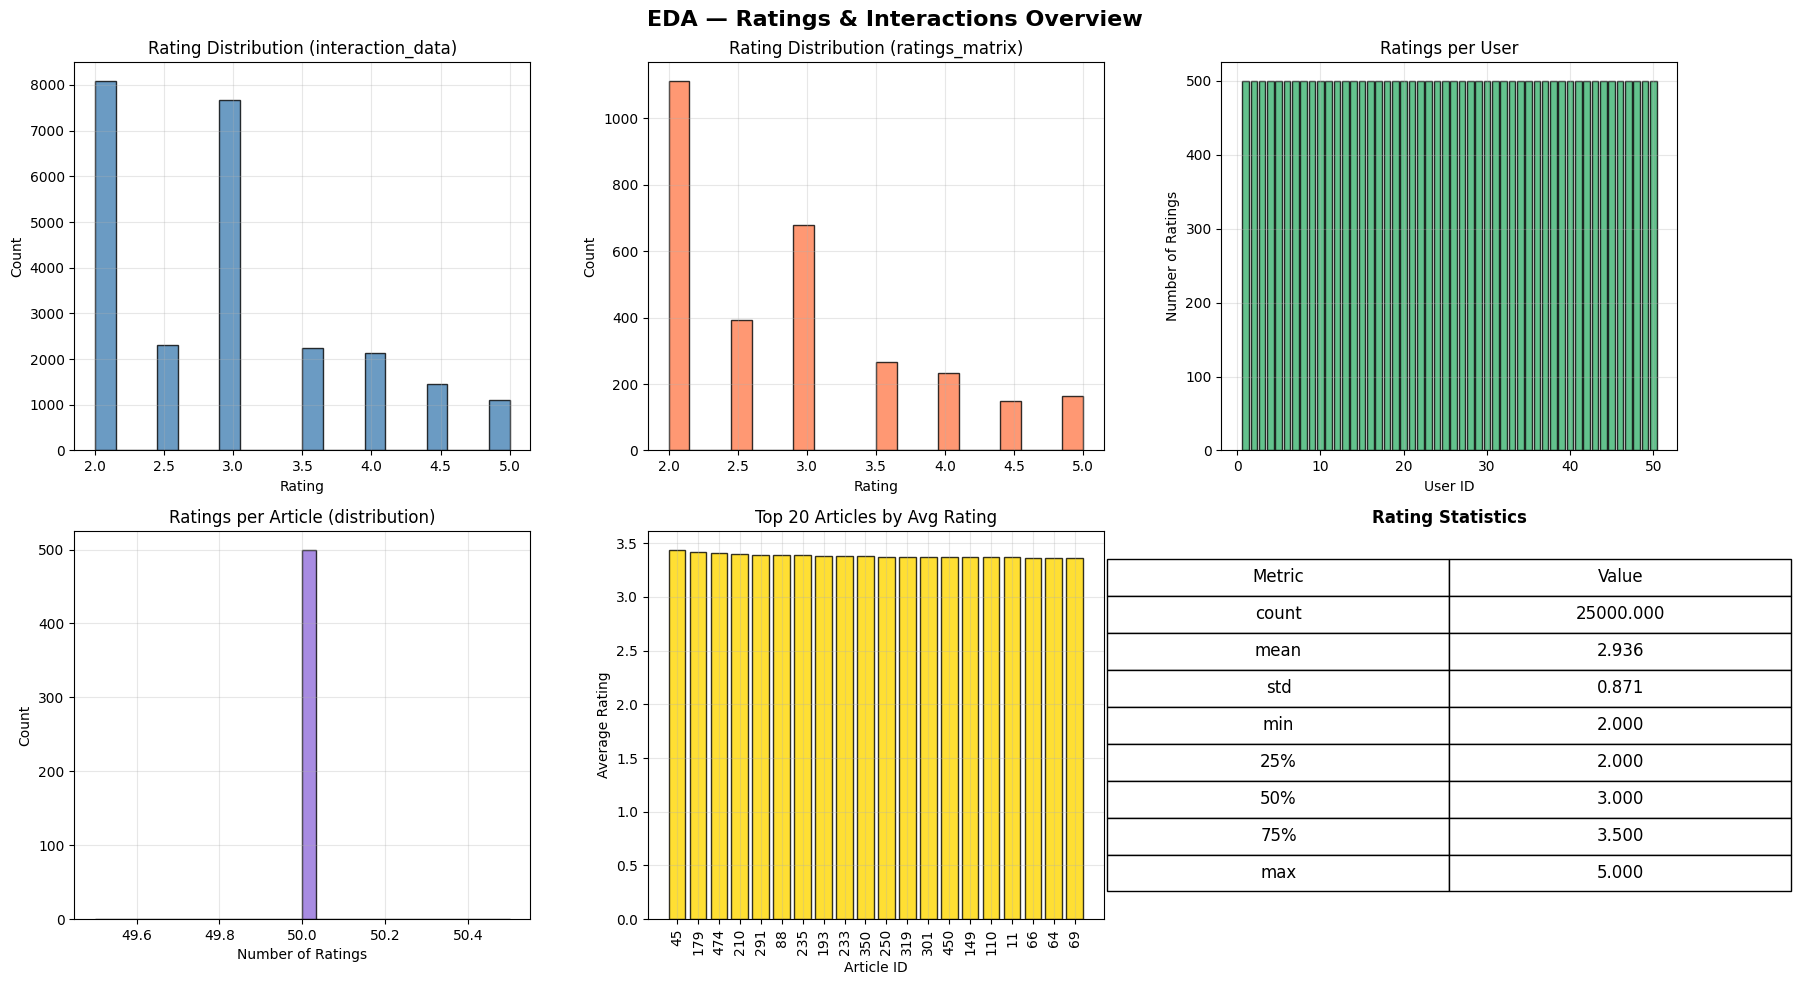


Unique users    : 50
Unique articles : 500
Total ratings   : 25000
Rating range    : 2.0 → 5.0
Sparsity        : 0.0000


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA — Ratings & Interactions Overview', fontsize=16, fontweight='bold')

# 1. Rating distribution — interaction_data
axes[0,0].hist(interaction_data['rating'], bins=20,
               color='steelblue', edgecolor='black', alpha=0.8)
axes[0,0].set_title('Rating Distribution (interaction_data)')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Count')
axes[0,0].grid(True, alpha=0.3)

# 2. Rating distribution — ratings_matrix
axes[0,1].hist(ratings_matrix['rating'], bins=20,
               color='coral', edgecolor='black', alpha=0.8)
axes[0,1].set_title('Rating Distribution (ratings_matrix)')
axes[0,1].set_xlabel('Rating')
axes[0,1].set_ylabel('Count')
axes[0,1].grid(True, alpha=0.3)

# 3. Ratings per user
ratings_per_user = interaction_data.groupby('user_id')['rating'].count()
axes[0,2].bar(ratings_per_user.index, ratings_per_user.values,
              color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[0,2].set_title('Ratings per User')
axes[0,2].set_xlabel('User ID')
axes[0,2].set_ylabel('Number of Ratings')
axes[0,2].grid(True, alpha=0.3)

# 4. Ratings per article
ratings_per_article = interaction_data.groupby('article_id')['rating'].count()
axes[1,0].hist(ratings_per_article.values, bins=30,
               color='mediumpurple', edgecolor='black', alpha=0.8)
axes[1,0].set_title('Ratings per Article (distribution)')
axes[1,0].set_xlabel('Number of Ratings')
axes[1,0].set_ylabel('Count')
axes[1,0].grid(True, alpha=0.3)

# 5. Average rating per article (top 20)
avg_per_article = interaction_data.groupby('article_id')['rating'].mean().sort_values(ascending=False).head(20)
axes[1,1].bar(avg_per_article.index.astype(str), avg_per_article.values,
              color='gold', edgecolor='black', alpha=0.8)
axes[1,1].set_title('Top 20 Articles by Avg Rating')
axes[1,1].set_xlabel('Article ID')
axes[1,1].set_ylabel('Average Rating')
axes[1,1].tick_params(axis='x', rotation=90)
axes[1,1].grid(True, alpha=0.3)

# 6. Rating stats summary
stats = interaction_data['rating'].describe()
axes[1,2].axis('off')
table_data = [[k, f"{v:.3f}"] for k, v in stats.items()]
table = axes[1,2].table(cellText=table_data,
                         colLabels=['Metric', 'Value'],
                         loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 2)
axes[1,2].set_title('Rating Statistics', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nUnique users    : {interaction_data['user_id'].nunique()}")
print(f"Unique articles : {interaction_data['article_id'].nunique()}")
print(f"Total ratings   : {len(interaction_data)}")
print(f"Rating range    : {interaction_data['rating'].min()} → {interaction_data['rating'].max()}")
print(f"Sparsity        : {1 - len(ratings_matrix)/(ratings_matrix['user_id'].nunique()*ratings_matrix['article_id'].nunique()):.4f}")

In [5]:
print("="*60)
print("MODEL 4: HYBRID MULTI-TOWER NEURAL NETWORK")
print("="*60)

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
import time
import json
import os
from datetime import timedelta
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)
os.makedirs('saved_models', exist_ok=True)

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU available: {gpus}")
else:
    print("No GPU — running on CPU")

# ── Feature column definitions ────────────────────────────
USER_COLS = [c for c in interaction_data.columns
             if c.startswith('user_preference_')
             or c.startswith('user_type_')
             or (c.startswith('presentation_type_') and c.endswith('_x'))]

ITEM_COLS = [c for c in interaction_data.columns
             if c in ['Boring presentation','Graphics','Readability',
                      'Consistency','Images','Bullets','Text size',
                      'Text heavy','Tables','Agenda','Infographics',
                      'Positioning','Presentation length','General tips',
                      'Presentation skills','Powerpoint knowledge',
                      'tips and tricks','Explanation of the problem']
             or (c.startswith('presentation_type_') and c.endswith('_y'))
             or c.startswith('audience_type_')]

PROBLEM_COLS = [c for c in interaction_data.columns
                if c in ['Boring presentation','Graphics','Readability',
                         'Consistency','Images','Bullets','Text size',
                         'Text heavy','Tables','Agenda','Infographics',
                         'Positioning']]

print(f"User  features : {len(USER_COLS)}")
print(f"Item  features : {len(ITEM_COLS)}")
print(f"Problem cols   : {len(PROBLEM_COLS)}")

MODEL 4: HYBRID MULTI-TOWER NEURAL NETWORK
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
User  features : 31
Item  features : 36
Problem cols   : 12


In [7]:
X_user = df_h[USER_COLS].values.astype(np.float32)
X_item = df_h[ITEM_COLS].values.astype(np.float32)
X_time = df_h[TIME_COLS].values.astype(np.float32)
X_prob = df_h[PROB_COLS].values.astype(np.float32)
y      = df_h['rating'].values.astype(np.float32)

idx = np.arange(len(y))
train_idx, temp_idx = train_test_split(idx, test_size=0.30, random_state=42)
val_idx,   test_idx = train_test_split(temp_idx, test_size=0.50, random_state=42)

def split(arr):
    return arr[train_idx], arr[val_idx], arr[test_idx]

Xu_tr, Xu_va, Xu_te = split(X_user)
Xi_tr, Xi_va, Xi_te = split(X_item)
Xt_tr, Xt_va, Xt_te = split(X_time)
Xp_tr, Xp_va, Xp_te = split(X_prob)
y_tr,  y_va,  y_te  = split(y)

print(f"Train : {len(y_tr):,} | Val : {len(y_va):,} | Test : {len(y_te):,}")
print(f"User  dim : {X_user.shape[1]}")
print(f"Item  dim : {X_item.shape[1]}")
print(f"Time  dim : {X_time.shape[1]}")
print(f"Prob  dim : {X_prob.shape[1]}")

Train : 17,500 | Val : 3,750 | Test : 3,750
User  dim : 31
Item  dim : 36
Time  dim : 5
Prob  dim : 12


In [8]:
def build_hybrid_model(user_dim, item_dim, time_dim, prob_dim,
                       user_units=128, item_units=256,
                       time_units=16,  prob_units=32,
                       dropout=0.3,    lr=5.17e-4):
    """
    Exact architecture from paper Table 5:
    User Tower  : Dense 128 → BN → Dropout → Embed 16
    Item Tower  : Dense 256 → BN → Dropout → Embed 16
    Time Tower  : Dense 16  → BN → Dropout
    Problem Tower: Dense 32 → BN → Dropout → Proj 32
    Concat → Dense 128 → BN → Dropout → Dense 32 → Output
    """
    reg = tf.keras.regularizers.l2(1e-5)

    # Inputs
    user_inp = Input(shape=(user_dim,), name='user_feat_input')
    item_inp = Input(shape=(item_dim,), name='item_feat_input')
    time_inp = Input(shape=(time_dim,), name='time_input')
    prob_inp = Input(shape=(prob_dim,), name='problem_seq_input')

    # User Tower
    u = layers.Dense(user_units, activation='relu',
                     kernel_regularizer=reg,
                     name='dense_user')(user_inp)
    u = layers.BatchNormalization(name='bn_user')(u)
    u = layers.Dropout(dropout, name='dropout_user')(u)
    u = layers.Dense(16, activation='relu',
                     name='dense_user_embed')(u)

    # Item Tower
    it = layers.Dense(item_units, activation='relu',
                      kernel_regularizer=reg,
                      name='dense_item')(item_inp)
    it = layers.BatchNormalization(name='bn_item')(it)
    it = layers.Dropout(dropout, name='dropout_item')(it)
    it = layers.Dense(16, activation='relu',
                      name='dense_item_embed')(it)

    # Time Tower
    t = layers.Dense(time_units, activation='relu',
                     name='dense_time')(time_inp)
    t = layers.BatchNormalization(name='bn_time')(t)
    t = layers.Dropout(dropout, name='dropout_time')(t)

    # Problem Tower
    p = layers.Dense(prob_units, activation='relu',
                     name='dense_problem_seq')(prob_inp)
    p = layers.BatchNormalization(name='bn_problem_seq')(p)
    p = layers.Dropout(dropout, name='dropout_problem_seq')(p)
    p = layers.Dense(32, activation='relu',
                     name='dense_problem_seq_proj')(p)

    # Fusion
    merged = layers.Concatenate(name='concat_embedding')([u, it, t, p])

    x = layers.Dense(128, activation='relu',
                     name='dense_combined')(merged)
    x = layers.BatchNormalization(name='bn_combined')(x)
    x = layers.Dropout(dropout, name='dropout_combined')(x)
    x = layers.Dense(32, activation='relu',
                     name='dense_hidden')(x)
    output = layers.Dense(1, activation='linear',
                          name='output')(x)

    model = Model(
        inputs=[user_inp, item_inp, time_inp, prob_inp],
        outputs=output,
        name='HybridMultiTower'
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='mse',
        metrics=['mae']
    )
    return model

# Preview
preview = build_hybrid_model(
    user_dim=len(USER_COLS), item_dim=len(ITEM_COLS),
    time_dim=len(TIME_COLS), prob_dim=len(PROB_COLS)
)
preview.summary()
print(f"\nTotal parameters: {preview.count_params():,}")

I0000 00:00:1774170048.610858      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774170048.616758      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "HybridMultiTower"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_feat_input     │ (None, 31)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_feat_input     │ (None, 36)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ problem_seq_input   │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_user (Dense)  │ (None, 128)       │      4,096 │ user_feat_input[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_item (Dense)  │ (None, 256)       │      9,472 │ item_feat_input[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_input          │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_problem_seq   │ (None, 32)        │        416 │ problem_seq_inpu… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_user             │ (None, 128)       │        512 │ dense_user[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_item             │ (None, 256)       │      1,024 │ dense_item[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_time (Dense)  │ (None, 16)        │         96 │ time_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_problem_seq      │ (None, 32)        │        128 │ dense_problem_se… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_user        │ (None, 128)       │          0 │ bn_user[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_item        │ (None, 256)       │          0 │ bn_item[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_time             │ (None, 16)        │         64 │ dense_time[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_problem_seq │ (None, 32)        │          0 │ bn_problem_seq[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_user_embed    │ (None, 16)        │      2,064 │ dropout_user[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_item_embed    │ (None, 16)        │      4,112 │ dropout_item[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_time        │ (None, 16)        │          0 │ bn_time[0][0]   

 Total params: 38,081 (148.75 KB)

 Trainable params: 36,961 (144.38 KB)

 Non-trainable params: 1,120 (4.38 KB)


Total parameters: 38,081


In [9]:
print("="*60)
print("STEP 1: HYPERPARAMETER TUNING")
print("="*60)

configs_h = [
    {'user_u':128, 'item_u':256, 'drop':0.3, 'lr':5.17e-4},
    {'user_u':128, 'item_u':256, 'drop':0.2, 'lr':1e-3},
    {'user_u':64,  'item_u':256, 'drop':0.3, 'lr':5e-4},
    {'user_u':128, 'item_u':128, 'drop':0.2, 'lr':1e-3},
    {'user_u':128, 'item_u':256, 'drop':0.4, 'lr':5e-4},
]

tune_results_h = []

for i, cfg in enumerate(configs_h):
    print(f"\nConfig {i+1}/{len(configs_h)}: {cfg}")

    m = build_hybrid_model(
        user_dim=len(USER_COLS), item_dim=len(ITEM_COLS),
        time_dim=len(TIME_COLS), prob_dim=len(PROB_COLS),
        user_units=cfg['user_u'], item_units=cfg['item_u'],
        dropout=cfg['drop'],      lr=cfg['lr']
    )

    es = EarlyStopping(monitor='val_loss', patience=5,
                       restore_best_weights=True, verbose=0)

    h = m.fit(
        [Xu_tr, Xi_tr, Xt_tr, Xp_tr], y_tr,
        validation_data=([Xu_va, Xi_va, Xt_va, Xp_va], y_va),
        epochs=20, batch_size=256,
        callbacks=[es], verbose=1
    )

    bvl   = min(h.history['val_loss'])
    bvmae = min(h.history['val_mae'])
    btl   = min(h.history['loss'])
    btmae = min(h.history['mae'])
    ep    = len(h.history['loss'])

    print(f"  Epochs     : {ep}")
    print(f"  Train loss : {btl:.4f} | Val loss : {bvl:.4f}")
    print(f"  Train MAE  : {btmae:.4f} | Val MAE  : {bvmae:.4f}")

    tune_results_h.append({
        'config'    : cfg,
        'val_loss'  : bvl,
        'val_mae'   : bvmae,
        'train_loss': btl,
        'train_mae' : btmae,
        'epochs'    : ep
    })

print("\n" + "="*60)
print("TUNING SUMMARY")
print("="*60)
print(f"{'Cfg':<5}{'Train Loss':>12}{'Val Loss':>10}"
      f"{'Train MAE':>11}{'Val MAE':>9}{'Epochs':>7}")
print("-"*55)
for i, r in enumerate(tune_results_h):
    print(f"  {i+1:<4}{r['train_loss']:>12.4f}{r['val_loss']:>10.4f}"
          f"{r['train_mae']:>11.4f}{r['val_mae']:>9.4f}{r['epochs']:>7}")

best_h     = min(tune_results_h, key=lambda x: x['val_mae'])
best_cfg_h = best_h['config']
print(f"\nBest config  : {best_cfg_h}")
print(f"Best val MAE : {best_h['val_mae']:.4f}")

STEP 1: HYPERPARAMETER TUNING

Config 1/5: {'user_u': 128, 'item_u': 256, 'drop': 0.3, 'lr': 0.000517}
Epoch 1/20


I0000 00:00:1774170075.744543     165 service.cc:152] XLA service 0x7aa690003c50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774170075.744587     165 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774170075.744593     165 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774170076.707628     165 cuda_dnn.cc:529] Loaded cuDNN version 91002


50/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12.2254 - mae: 3.2387

I0000 00:00:1774170081.404093     165 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


69/69 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - loss: 11.1610 - mae: 3.0598 - val_loss: 5.6874 - val_mae: 2.2290
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0485 - mae: 1.1430 - val_loss: 1.8381 - val_mae: 1.0982
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0445 - mae: 0.7969 - val_loss: 0.7648 - val_mae: 0.6740
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8351 - mae: 0.7133 - val_loss: 0.5157 - val_mae: 0.5565
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6944 - mae: 0.6503 - val_loss: 0.4365 - val_mae: 0.5328
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6480 - mae: 0.6241 - val_loss: 0.3898 - val_mae: 0.5084
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5829 - mae: 0.5891 - val_loss: 0.3527 - val_mae: 0.4819
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5491 - mae: 0.5721 - val_loss: 0.3447 - val_mae: 0.4800
Epoch 9/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5243 - mae: 0.5563 -

In [10]:
print("="*60)
print("STEP 2: TRAINING FINAL MODEL")
print("="*60)

hybrid_model = build_hybrid_model(
    user_dim=len(USER_COLS), item_dim=len(ITEM_COLS),
    time_dim=len(TIME_COLS), prob_dim=len(PROB_COLS),
    user_units=best_cfg_h['user_u'],
    item_units=best_cfg_h['item_u'],
    dropout   =best_cfg_h['drop'],
    lr        =best_cfg_h['lr']
)

callbacks_h = [
    EarlyStopping(monitor='val_loss', patience=20,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1),
    ModelCheckpoint('saved_models/hybrid_best.keras',
                    monitor='val_loss',
                    save_best_only=True, verbose=1)
]

start = time.time()
history_h = hybrid_model.fit(
    [Xu_tr, Xi_tr, Xt_tr, Xp_tr], y_tr,
    validation_data=([Xu_va, Xi_va, Xt_va, Xp_va], y_va),
    epochs=200,
    batch_size=256,
    callbacks=callbacks_h,
    verbose=1
)
time_hybrid = time.time() - start

best_train_loss_h = min(history_h.history['loss'])
best_val_loss_h   = min(history_h.history['val_loss'])
best_train_mae_h  = min(history_h.history['mae'])
best_val_mae_h    = min(history_h.history['val_mae'])
total_epochs_h    = len(history_h.history['loss'])

print(f"\nTraining time    : {str(timedelta(seconds=int(time_hybrid)))}")
print(f"Epochs ran       : {total_epochs_h}")
print(f"Best train loss  : {best_train_loss_h:.4f}")
print(f"Best val loss    : {best_val_loss_h:.4f}")
print(f"Best train MAE   : {best_train_mae_h:.4f}")
print(f"Best val MAE     : {best_val_mae_h:.4f}")

STEP 2: TRAINING FINAL MODEL
Epoch 1/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 9.5915 - mae: 2.6366
Epoch 1: val_loss improved from inf to 3.29427, saving model to saved_models/hybrid_best.keras
69/69 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step - loss: 9.5246 - mae: 2.6234 - val_loss: 3.2943 - val_mae: 1.6171 - learning_rate: 0.0010
Epoch 2/200
64/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9053 - mae: 0.7434
Epoch 2: val_loss improved from 3.29427 to 1.17392, saving model to saved_models/hybrid_best.keras
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8971 - mae: 0.7398 - val_loss: 1.1739 - val_mae: 0.8183 - learning_rate: 0.0010
Epoch 3/200
64/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6178 - mae: 0.6096
Epoch 3: val_loss improved from 1.17392 to 0.62596, saving model to saved_models/hybrid_best.keras
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6162 - mae: 0.6088 - val_loss: 0.6260 - val_mae: 0.5874 - learning_rate: 0.0010
Epoch 4/200
66/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/st

In [11]:
print("="*60)
print("STEP 3: TEST SET EVALUATION")
print("="*60)

y_pred_h4 = hybrid_model.predict(
    [Xu_te, Xi_te, Xt_te, Xp_te],
    batch_size=512, verbose=1
).flatten()

y_pred_h4 = np.clip(y_pred_h4, 2.0, 5.0)

mae_h4  = mean_absolute_error(y_te, y_pred_h4)
mse_h4  = mean_squared_error(y_te, y_pred_h4)
rmse_h4 = np.sqrt(mse_h4)

print("\n" + "="*65)
print("  MODEL 4: HYBRID MULTI-TOWER — FINAL RESULTS")
print("="*65)
print(f"  MAE  : {mae_h4:.4f}   (paper: 0.11)")
print(f"  MSE  : {mse_h4:.4f}   (paper: 0.033)")
print(f"  RMSE : {rmse_h4:.4f}   (paper: 0.18)")
print(f"  Time : {str(timedelta(seconds=int(time_hybrid)))}")
print(f"\n  Beats paper? {'YES' if mae_h4 < 0.11 else 'NO'}")
print("="*65)

STEP 3: TEST SET EVALUATION
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step

  MODEL 4: HYBRID MULTI-TOWER — FINAL RESULTS
  MAE  : 0.0803   (paper: 0.11)
  MSE  : 0.0254   (paper: 0.033)
  RMSE : 0.1595   (paper: 0.18)
  Time : 0:01:38

  Beats paper? YES


In [12]:
os.makedirs('saved_models', exist_ok=True)

hybrid_model.save('saved_models/hybrid_model_final.keras')

hybrid_metrics = {
    'model'          : 'Hybrid Multi-Tower',
    'best_config'    : str(best_cfg_h),
    'total_epochs'   : total_epochs_h,
    'training_time'  : str(timedelta(seconds=int(time_hybrid))),
    'best_train_loss': round(best_train_loss_h, 4),
    'best_val_loss'  : round(best_val_loss_h,   4),
    'best_train_mae' : round(best_train_mae_h,  4),
    'best_val_mae'   : round(best_val_mae_h,    4),
    'test_MAE'       : round(float(mae_h4),     4),
    'test_MSE'       : round(float(mse_h4),     4),
    'test_RMSE'      : round(float(rmse_h4),    4),
    'paper_MAE'      : 0.11,
    'beats_paper'    : bool(mae_h4 < 0.11)
}

with open('saved_models/hybrid_metrics.json', 'w') as f:
    json.dump(hybrid_metrics, f, indent=2)

print("Saved:")
print("  saved_models/hybrid_model_final.keras")
print("  saved_models/hybrid_metrics.json")
print(f"\n  Beats paper? {'YES' if mae_h4 < 0.11 else 'NO'}")
print(f"  Paper MAE : 0.11 | Our MAE : {mae_h4:.4f}")

Saved:
  saved_models/hybrid_model_final.keras
  saved_models/hybrid_metrics.json

  Beats paper? YES
  Paper MAE : 0.11 | Our MAE : 0.0803


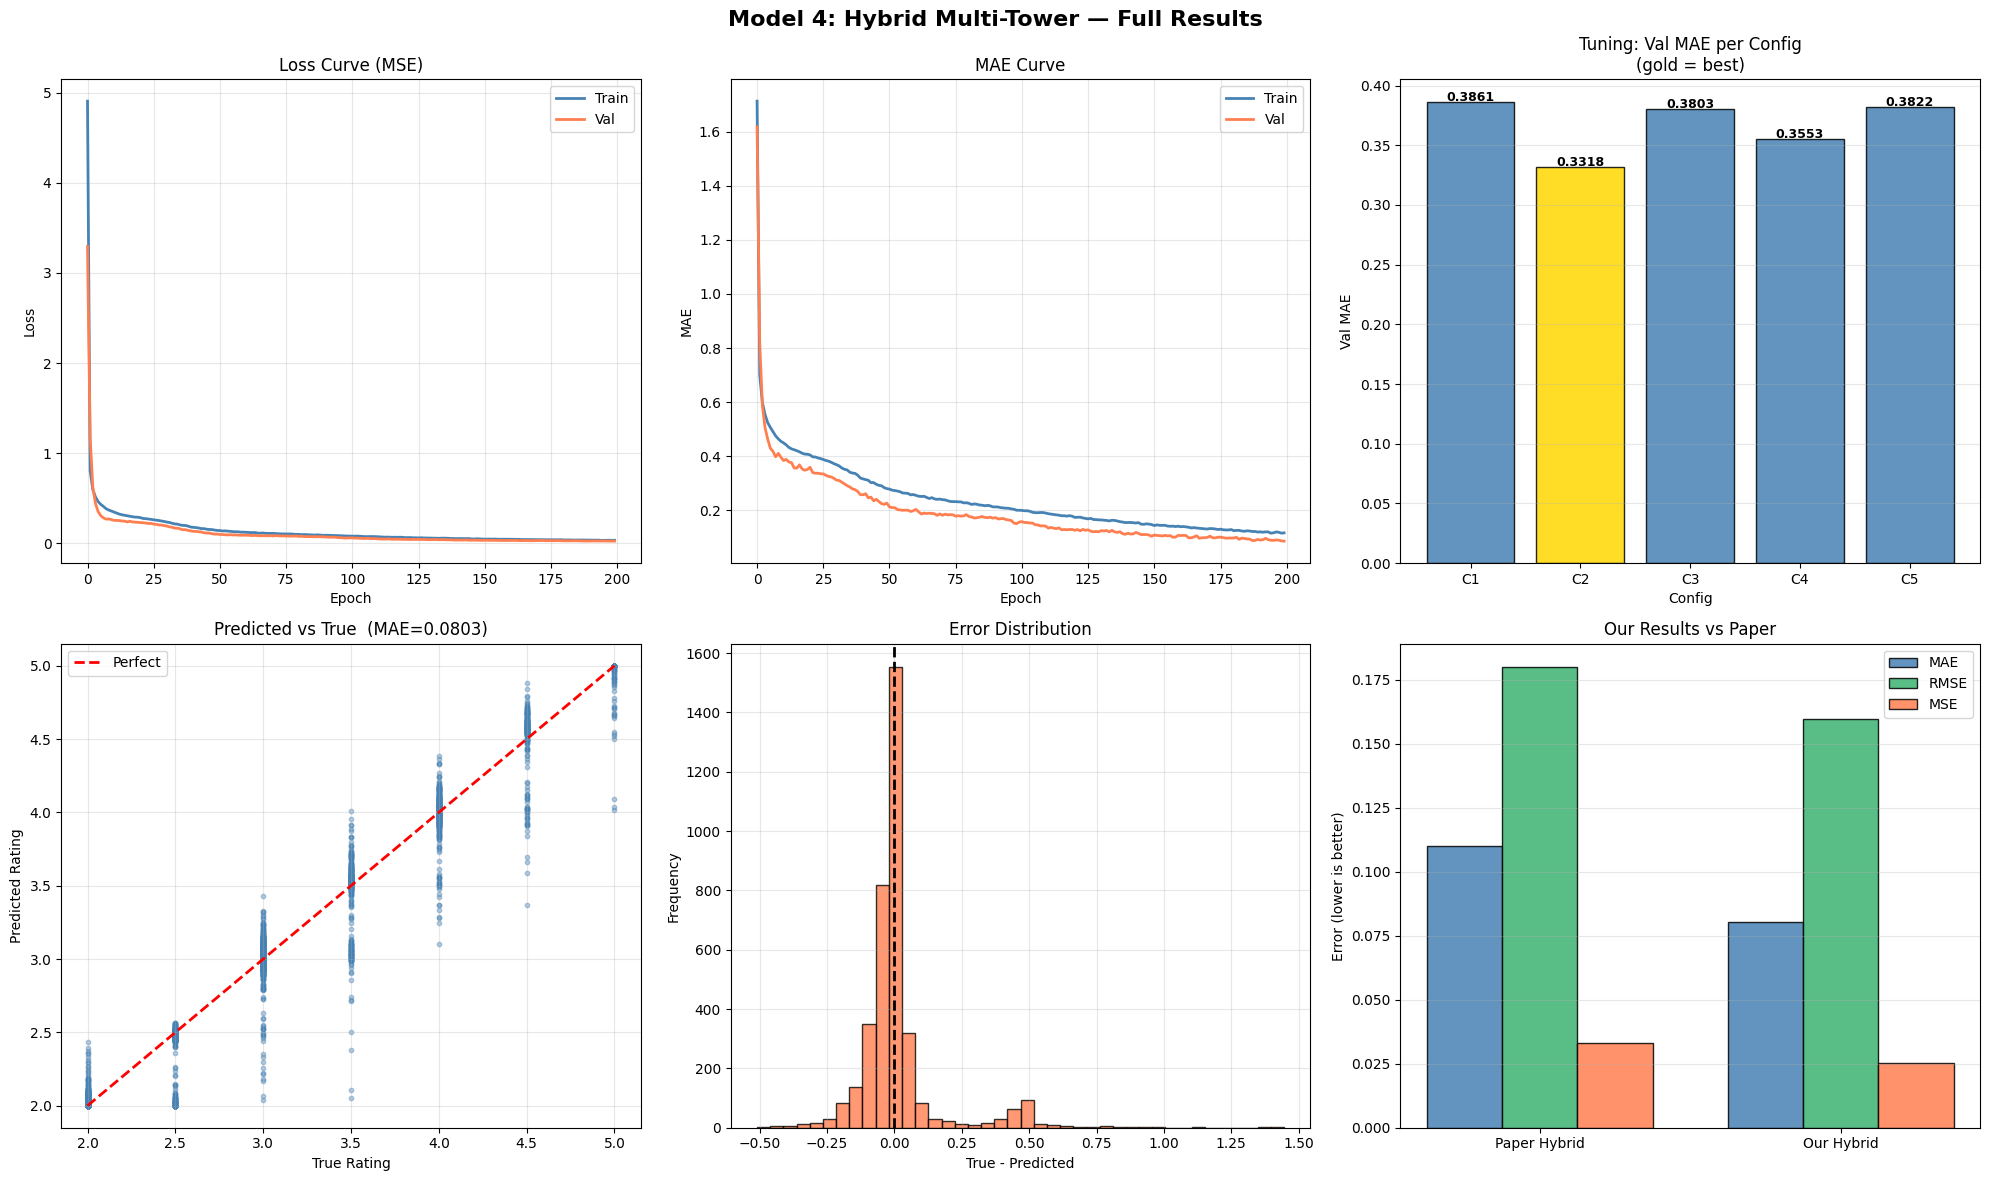


  FINAL SUMMARY — MODEL 4: HYBRID MULTI-TOWER
  Best config      : {'user_u': 128, 'item_u': 256, 'drop': 0.2, 'lr': 0.001}
  Epochs ran       : 200
  Training time    : 0:01:38
  Best train loss  : 0.0335
  Best val loss    : 0.0257
  Best train MAE   : 0.1158
  Best val MAE     : 0.0865
  Test MAE         : 0.0803   (paper: 0.11)
  Test MSE         : 0.0254   (paper: 0.033)
  Test RMSE        : 0.1595   (paper: 0.18)
  Beats paper?     : YES


In [13]:
%matplotlib inline

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Model 4: Hybrid Multi-Tower — Full Results',
             fontsize=16, fontweight='bold')

# Loss curve
axes[0,0].plot(history_h.history['loss'],
               label='Train', linewidth=2, color='steelblue')
axes[0,0].plot(history_h.history['val_loss'],
               label='Val',   linewidth=2, color='coral')
axes[0,0].set_title('Loss Curve (MSE)')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# MAE curve
axes[0,1].plot(history_h.history['mae'],
               label='Train', linewidth=2, color='steelblue')
axes[0,1].plot(history_h.history['val_mae'],
               label='Val',   linewidth=2, color='coral')
axes[0,1].set_title('MAE Curve')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('MAE')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Tuning comparison
config_labels = [f"C{i+1}" for i in range(len(tune_results_h))]
val_maes      = [r['val_mae'] for r in tune_results_h]
best_idx      = val_maes.index(min(val_maes))
bar_colors    = ['gold' if i == best_idx else 'steelblue'
                 for i in range(len(config_labels))]
bars = axes[0,2].bar(config_labels, val_maes,
                      color=bar_colors, edgecolor='black', alpha=0.85)
axes[0,2].set_title('Tuning: Val MAE per Config\n(gold = best)')
axes[0,2].set_xlabel('Config')
axes[0,2].set_ylabel('Val MAE')
axes[0,2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, val_maes):
    axes[0,2].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.001,
                   f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

# Predicted vs True
axes[1,0].scatter(y_te, y_pred_h4,
                  alpha=0.4, s=10, color='steelblue')
axes[1,0].plot([2, 5], [2, 5], 'r--', linewidth=2, label='Perfect')
axes[1,0].set_title(f'Predicted vs True  (MAE={mae_h4:.4f})')
axes[1,0].set_xlabel('True Rating')
axes[1,0].set_ylabel('Predicted Rating')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Error distribution
errors_h = y_te - y_pred_h4
axes[1,1].hist(errors_h, bins=40,
               color='coral', edgecolor='black', alpha=0.8)
axes[1,1].axvline(0, color='black', linestyle='--', linewidth=2)
axes[1,1].set_title('Error Distribution')
axes[1,1].set_xlabel('True - Predicted')
axes[1,1].set_ylabel('Frequency')
axes[1,1].grid(True, alpha=0.3)

# Our results vs paper
x_pos    = np.arange(2)
w        = 0.25
axes[1,2].bar(x_pos - w, [0.11,  mae_h4],  width=w, label='MAE',
              color='steelblue',      edgecolor='black', alpha=0.85)
axes[1,2].bar(x_pos,     [0.18,  rmse_h4], width=w, label='RMSE',
              color='mediumseagreen', edgecolor='black', alpha=0.85)
axes[1,2].bar(x_pos + w, [0.033, mse_h4],  width=w, label='MSE',
              color='coral',          edgecolor='black', alpha=0.85)
axes[1,2].set_title('Our Results vs Paper')
axes[1,2].set_xticks(x_pos)
axes[1,2].set_xticklabels(['Paper Hybrid', 'Our Hybrid'])
axes[1,2].set_ylabel('Error (lower is better)')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('saved_models/hybrid_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*65)
print("  FINAL SUMMARY — MODEL 4: HYBRID MULTI-TOWER")
print("="*65)
print(f"  Best config      : {best_cfg_h}")
print(f"  Epochs ran       : {total_epochs_h}")
print(f"  Training time    : {str(timedelta(seconds=int(time_hybrid)))}")
print(f"  Best train loss  : {best_train_loss_h:.4f}")
print(f"  Best val loss    : {best_val_loss_h:.4f}")
print(f"  Best train MAE   : {best_train_mae_h:.4f}")
print(f"  Best val MAE     : {best_val_mae_h:.4f}")
print(f"  Test MAE         : {mae_h4:.4f}   (paper: 0.11)")
print(f"  Test MSE         : {mse_h4:.4f}   (paper: 0.033)")
print(f"  Test RMSE        : {rmse_h4:.4f}   (paper: 0.18)")
print(f"  Beats paper?     : {'YES' if mae_h4 < 0.11 else 'NO'}")
print("="*65)